In [6]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os
import seaborn as sns

#  Results - Diffusion-Based Data Augmentation: Parameter-Efficient Fine-Tuning of Cheff for Rare Pathologies
This notebook provides a summary of the project's results, including the fine-tuning of the Cheff diffusion model, the performance of downstream pathology classifiers, and an analysis of synthetic data filtering strategies.

## 1. Cheff LoRA Finetuning
To adapt the original Cheff model (trained on adult radiographs) to the pediatric domain, we employed Parameter-Efficient Fine-Tuning (PEFT) via LoRA.

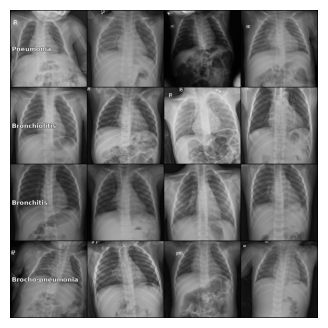

In [44]:
plt.figure(figsize=(4, 4))
plt.imshow(plt.imread('cheff_lora_pcxr.png'))
plt.axis('off')
plt.show()

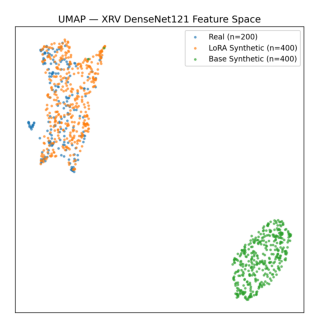

In [47]:
plt.figure(figsize=(4, 4))
plt.imshow(plt.imread('finetune_viz/umap.png'))
plt.axis('off')
plt.show()

## 2. Classifier Test Performance
We evaluate the classification performance across three experimental setups to determine the impact of diffusion-based data augmentation:

*   **Baseline**: Model trained solely on the VinDr-PCXR pediatric dataset.
*   **Synthetic**: Model trained on the dataset augmented with unfiltered synthetic images generated from the LoRA-adapted Cheff model.
*   **Synthetic Filtered**: Model trained with real data augmented by synthetic samples selected via an Oracle-based filtering strategy.

In [38]:
def load_metrics(path):
    with open(path, 'r') as f:
        return json.load(f)

runs_root = '../classifier/runs'
baseline_metrics = load_metrics(os.path.join(runs_root, 'baseline_slurm_ref/metrics.json'))
synthetic_metrics = load_metrics(os.path.join(runs_root, 'synthetic_slurm_ref/metrics.json'))
synthetic_filtered_metrics = load_metrics(os.path.join(runs_root, 'synthetic_filtered_slurm_ref/metrics.json'))

df_baseline = pd.DataFrame(baseline_metrics).T
df_synthetic = pd.DataFrame(synthetic_metrics).T
df_filtered = pd.DataFrame(synthetic_filtered_metrics).T

auroc_comparison = pd.DataFrame({
    'Baseline': df_baseline['auroc'],
    'Synthetic': df_synthetic['auroc'],
    'Synthetic Filtered': df_filtered['auroc']
}).T

auroc_comparison['Mean AUC'] = auroc_comparison.mean(axis=1)

print("AUROC Comparison: Pathologies and Macro Mean")
display(auroc_comparison.style.highlight_max(axis=0, color='grey'))

AUROC Comparison: Pathologies and Macro Mean


,No finding,Bronchitis,Brocho-pneumonia,Bronchiolitis,Pneumonia,Other disease,Mean AUC
Baseline,0.719009,0.686295,0.769539,0.696948,0.763787,0.622819,0.709733
Synthetic,0.711826,0.669345,0.762802,0.656287,0.748299,0.592621,0.690197
Synthetic Filtered,0.718772,0.695026,0.770509,0.698444,0.758702,0.635549,0.712834


### Performance Analysis
The results show that augmentation with the unfiltered synthetic data led to a performance decrease compared to the baseline. This is likely due to the noise inherent in the sampling of generative models. However, by employing Oracle filtering, performance could be recovered, matching or even slightly exceeding the baseline for specific pathologies. These results emphasize the importance of filtering the generated synthetic data.

## 3. Synthetic Filtering Analysis

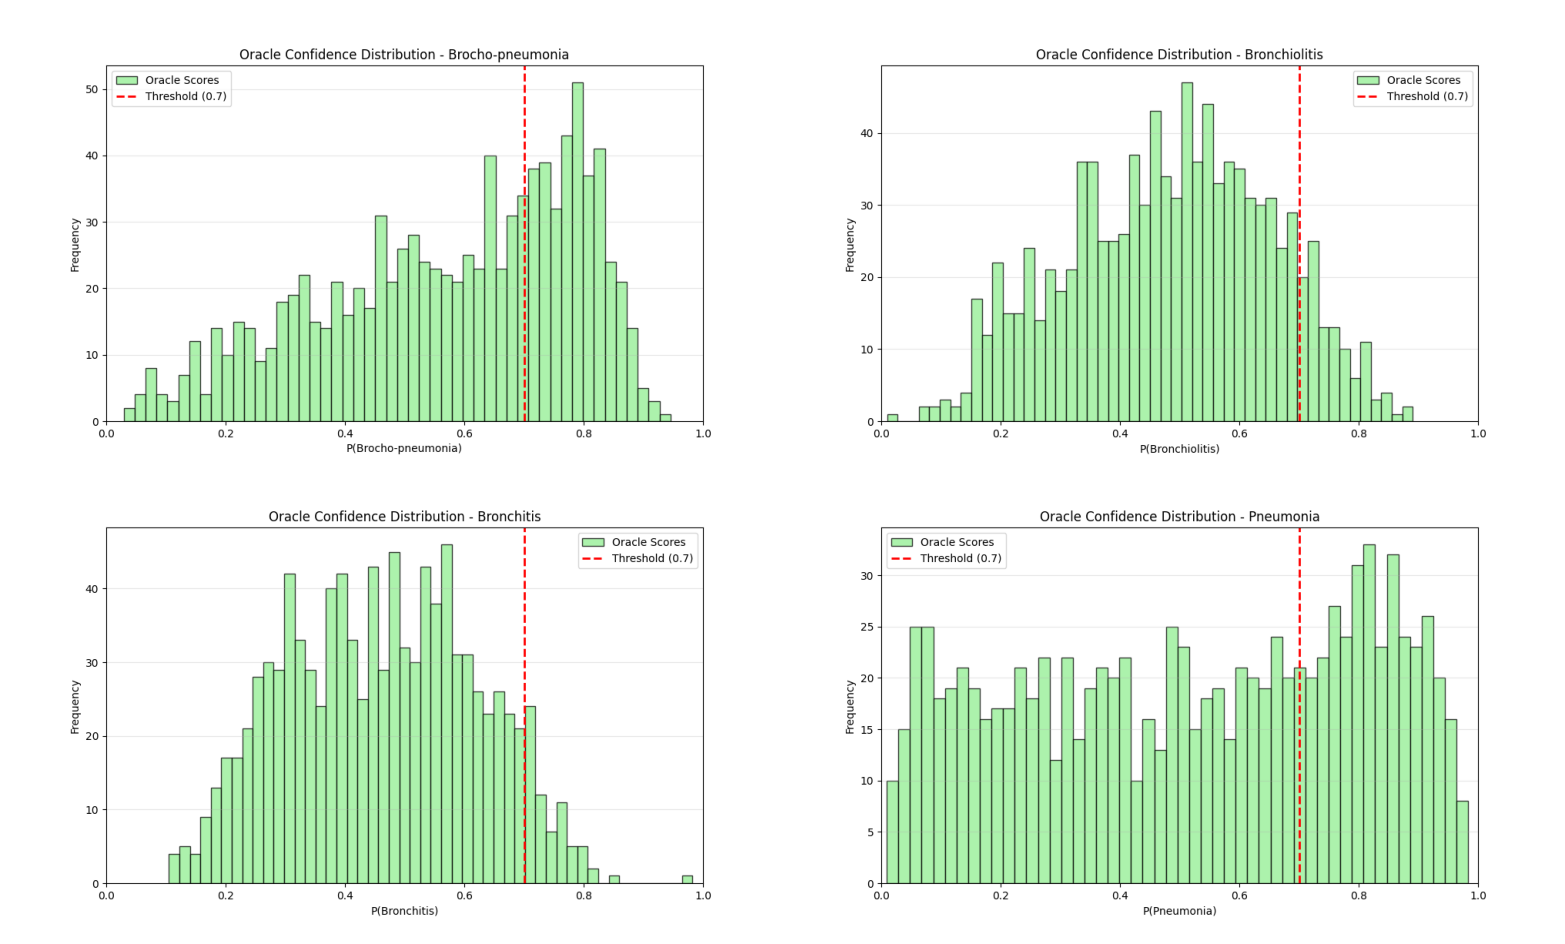

In [37]:
import matplotlib.pyplot as plt
import os

filter_runs_dir = '../classifier/runs/synthetic_filtered_slurm_ref'
oracle_images = [
    'oracle_distribution_Brocho-pneumonia.png',
    'oracle_distribution_Bronchiolitis.png',
    'oracle_distribution_Bronchitis.png',
    'oracle_distribution_Pneumonia.png'
]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, img_name in enumerate(oracle_images):
    img_path = os.path.join(filter_runs_dir, img_name)
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

The distribution of predicted probabilities for synthetic data varies significantly across pathologies. This likely stems from two factors: the relative complexity of synthesizing (or detecting) specific pathological features, and the inductive biases of the pretrained torchxrayvision classifier, which may be more attuned to certain conditions like Pneumonia due to its original training distribution.

Notably, Bronchitis exhibited the most substantial improvement in test performance. This is particularly striking given the stringent filtering used for this class, where only 108 synthetic samples were utilized for augmentation.

## 4. Classifier Training Stability
Finally, we visualize the validation AUC and training loss curves

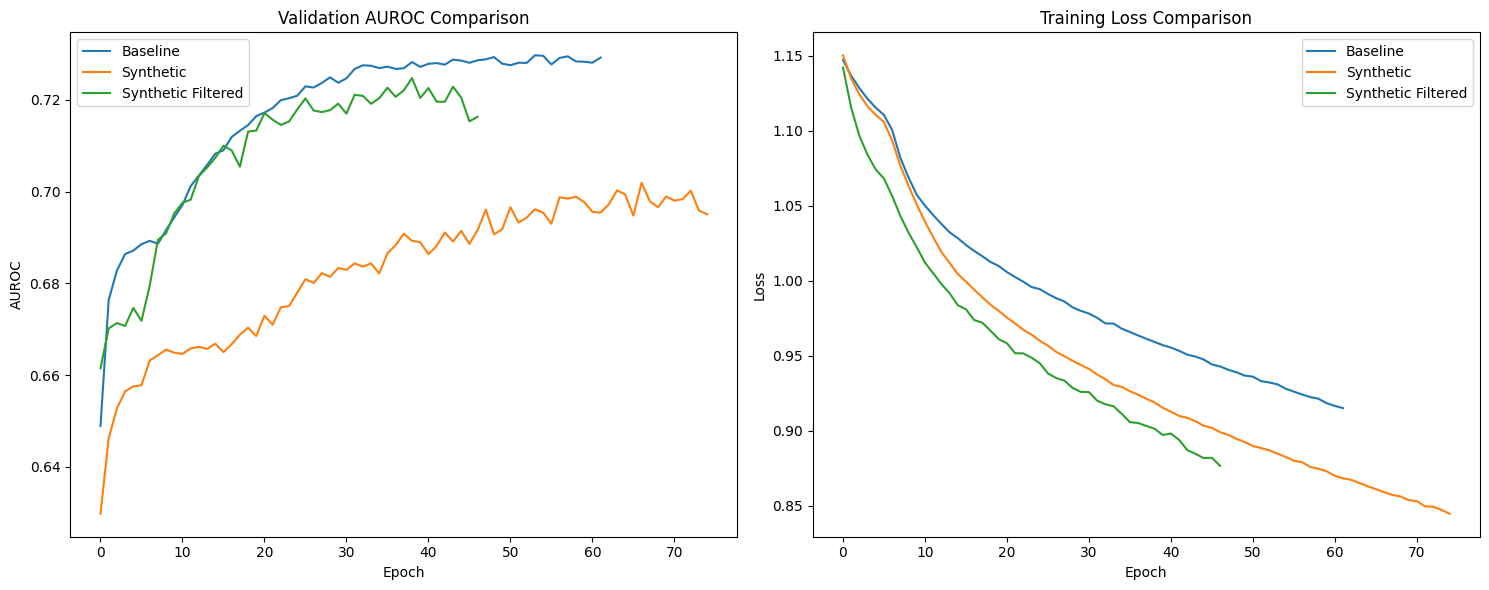

In [9]:
def load_training_logs(path):
    df = pd.read_csv(path)
    return df.groupby('epoch').mean().reset_index()

runs_root = '../classifier/runs'
df_baseline_train = load_training_logs(os.path.join(runs_root, 'baseline_slurm_ref/version_0/metrics.csv'))
df_synthetic_train = load_training_logs(os.path.join(runs_root, 'synthetic_slurm_ref/version_0/metrics.csv'))
df_filtered_train = load_training_logs(os.path.join(runs_root, 'synthetic_filtered_slurm_ref/version_0/metrics.csv'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(df_baseline_train['epoch'], df_baseline_train['val/auroc'], label='Baseline')
axes[0].plot(df_synthetic_train['epoch'], df_synthetic_train['val/auroc'], label='Synthetic')
axes[0].plot(df_filtered_train['epoch'], df_filtered_train['val/auroc'], label='Synthetic Filtered')
axes[0].set_title('Validation AUROC Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUROC')
axes[0].legend()

axes[1].plot(df_baseline_train['epoch'], df_baseline_train['train/loss'], label='Baseline')
axes[1].plot(df_synthetic_train['epoch'], df_synthetic_train['train/loss'], label='Synthetic')
axes[1].plot(df_filtered_train['epoch'], df_filtered_train['train/loss'], label='Synthetic Filtered')
axes[1].set_title('Training Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()